# Alberi di decisione

L'idea è quella di progettare un classificatore basato su una serie di test sulle caratteristiche in cui i test vengono scelti in funzione delle risposte precedenti. Si ottiene una struttura ad albero in cui i nodi interni sono relativi ai test, gli archi corrispondono agli esiti del test, e alle foglie corrispondono le decisioni (le classi).

![albero per iris](materiale_2026/10-1-albero_decisione_iris.png)

La figura mostra un classificatore del dataset Iris: su ogni nodo interno è riportato il test nella forma `f_i < val` dove `i` indica la colonna relativa alla caratteristica coinvolta.

Supponiamo che le decisioni siano binarie e che venga testata una caratteristica alla volta. Il modello si addestra in modo che ad ogni nodo corrisponda un l'insieme di esempi per i quali tutti i test nei nodi dalla radice sono soddisfatti. Il nuovo test è eseguito sulla feature con il maggior "guadagno informativo" rispetto agli esempi relativi al nodo. 

Vediamo cosa si intende per **guadagno informativo**. Sia $D_p$ l'insieme di esempi relativi al nodo $p$ e $n$ la sua cardinalità. Inoltre sia $n_c$ il numero di esempi in $D_p$ appartenenti alla classe $c$. Supponiamo di classificare un esempio $x$ in $D_p$ usando come distribuzione di probabilità quella implicata dalla distribuzione delle classi in $D_p$ allora la probabilità di errore nel classificare $x$ è data da

$$
I_G(D_p) = \sum_{c} \frac{n_c}{n}\left( 1 - \frac{n_c}{n} \right) = 1-\sum_{c}\left(\frac{n_c}{n} \right)^2
$$

in quanto $n_c/n$ è la probabilità di assegnare la classe $c$ (ma anche che $x$ appartenga alla classe $c$) mentre $1-n_c/n$ è la probabilità che $x$ non appartenga alla classe $c$. $I_G$ è detto indice di Gini: il suo valore tanto più basso quanto le cardinalità delle classi sono sbilanciate. Ad esempio se le classi fossero solo due allora

$$
I_G(D_p) = \frac{n_c}{n}\left( 1 - \frac{n_c}{n}  \right) + \frac{n-n_c}{n}\left( 1 - \frac{n-n_c}{n}  \right)
$$

che tende a $0$ con $n_c$ che tende a $0$ o a $n$ (una delle classi contiene quasi tutti i campioni). Il valore è massimo se le classi sono equidistribuite. Quindi $I_G$ è una sorta di misura dell'incertezza. Inoltre quando $I_G(D_p)$ è nullo, una delle classi prevale sull'altra quindi tutti i campioni appartengono ad una unica classe ed il nodo è considerato *puro*. Soltanto campioni con una stessa etichetta soddisfa la catena di condizioni che ha portato al nodo: ogni altro campione che soddisfa gli stessi vincoli può essere classificato con la stessa etichetta.  

In fase di addestramento, si vuole arrivare il prima possibile a nodi puri. Questo si ottiene dividendo i campioni relativi al nodo $p$ in due classi gruppi $D_L$ e $D_R$ che rappresentano i campioni associati al nodi sinistro e destro di $p$: se $I_G(D_L)$ e $I_G(D_R)$ sono simili a $I_G(D_p)$, la probabilità di sbagliare classificazione resta la stessa anche dopo il test sul nodo $p$, ovvero il test su $p$ non ha portato vantaggi. Un vantaggio lo otteniamo se $I_G(D_L)$ e $I_G(D_R)$ sono piccoli (la loro media pesata), ovvero se

$$
IG(D_p) = I_G(D_p) - \left( \frac{|D_L|}{n} I_G(D_L) + \frac{n-|D_L|}{n} I_G(D_R) \right)
$$

è massima. La funzione $IG$ è il **guadagno informativo**.

Concludendo, in fase di addestramento (creazione dell'albero), si sceglierà la feature e il valore che indurranno una partizione di $D_p$ che renda massimo il guadagno informativo.

Per misurare il livello di incertezza di un dataset, oltre alla funzione di Gini, può essere utilizzata la funzione **entropia** così definita

$$
I_H(D_p) = - \sum_{c} \frac{n_c}{n}\log_2 \frac{n_c}{n}
$$

che ha caratteristiche simili alla funzione di Gini. In questo contesto le $I_G$ e $I_H$ sono dette funzioni di *impurità*.

Durate l'addestramento, un nodo diventa foglia se gli esempi ad esso associati appartengono alla stessa classe $c$: questa sarà la classe con cui verrà classificato $x$ se la catena di condizioni su $x$ terminano su questa foglia. 

Si osservi che l'insieme di vincoli dell'albero determina delle regioni di decisioni rettangolari che possono diventare sempre più piccole man mano che la profondità dell'albero aumenta. In casi estremi si potrebbe giungere ad una regione rettangolare per ogni esempio: questo classificherebbe in modo corretto tutti gli esempi utilizzati per il training ma generalizzerebbe male (overfitting). Per questo motivo la profondità dell'albero è limitata a valori tra 3 e 4. Quando un nodo raggiunge la massima profondità consentita diventa foglia e l'etichetta gli verrà assegnata a maggioranza tra quelle del dataset corrispondente al nodo. Un nodo diventa foglia anche quando la dimensione del dataset è al di sotto di una certa soglia, anche i questo caso l'etichetta viene assegnata a maggioranza.

La funzione di impurità, l'altezza massima dell'albero, e la dimensione minima del dataset costituiscono gli iperparametri del modello.

## Implementazione

Un *nodo interno* è un dizionario con i seguenti campi:

- `'index'`: l'indice della colonna di `X` corrispondente alla caratteristica usata per il test;
- `'value'`: il valore con cui confrontare la caratteristica
- `'groups'`: una coppia che contiene $D_L$ e $D_R$
- `'left`, `'right'`: i riferimenti ai due figli

Un *nodo foglia* è semplicemente un valore, il nome della classe.


### Addestramento

Con $X$ indichiamo la matrice $n\times d$ degli $n$  campioni sulle $d$ di caratteristiche; con $y$ il vettore target. Per praticità durante l'addestramento viene utilizzato un dataset che concatena orizzontalmente $X$ e $y$, quindi le prime $n$ colonne del dataset corrispondono a $X$, l'ultima a $y$.

In [83]:
import os
import pandas as pd
import numpy as np
from graphviz import Digraph # per il disegno degli alberi

In [84]:
class DecisionTree(object):
    def __init__(self, max_depth=3, min_size=1):
        self.max_depth = max_depth
        self.min_size = min_size
        self.tree = None
        self._impurity_fun = self._gini

    def fit(self, X, y):
        """ Costruisce l'albero di decisione """
        y = np.array(y).reshape(-1, 1)  # una colonna x tutte le righe che servono
        
        '''
        dataset contiene sia X che y impilati verticalmente, questa è 
        la soluzione più conveniente per semplificare le operazioni
        di filtro delle righe che porterà alle suddivisioni del dataset che
        definiranno i nodi dell'albero
        '''
        dataset =  np.hstack((X, y)) # Concatenazione orizzontale
        self.tree = self._build_tree(dataset, 1)

    def _build_tree(self, dataset, depth):
        """ Costruisce l'albero a partire dai dati """
        root = self._get_best_split(dataset)
        self._split(root, depth)
        return root
    
    def _get_best_split(self, dataset):
        """ Trova la feature (colonna di dataset) sulla quale esiste un valore  che  
        Massimizza il guadagno informativo su tutte le possibili suddivisioni ottenibili usando
        tutte le possibili caratteristiche.

        Quindi per ogni caratteristica index e per ogni esempio row, si divide il dataset
        in base al test x[index] < row[index] e se ne calcola  il guadagno informativo.
        Si sceglie indx e row[index] in modo da massimizzare questo valore 
        """
        best_index, best_value, best_score, best_groups = None, None, float('-inf'), None
        for index in range(dataset.shape[1] - 1):  # Escludiamo la colonna target
            for row in dataset:
                groups = self._split_dataset(index, row[index], dataset)
                ig = self._info_gain(dataset, groups)
                if ig > best_score:
                    best_index, best_value, best_score, best_groups = index, row[index], ig, groups

        # ritorna un nodo
        return {'index': best_index, 'value': best_value, 'groups': best_groups}
    
    def _info_gain(self, dataset, groups):
        nl, nr = groups[0].shape[0], groups[1].shape[0]
        n = nl + nr
        ig = self._impurity_fun(dataset) - self._impurity_fun(groups[0])*nl/n - self._impurity_fun(groups[1])*nr/n
        return ig

    def _split_dataset(self, index, value, dataset):
        """ Divide il dataset in due gruppi in base al confronto della caratteristica
        index con value"""
        mask = dataset[:, index] < value
        left, right = dataset[mask], dataset[~mask]

        return left, right

    def _split(self, node, depth):
        """ Cresce l'albero ricorsivamente """
        left, right = node['groups']
        #del node['groups']
        
        # Se uno dei gruppi è vuoto, assegniamo una foglia
        if left.size == 0 or right.size == 0:
            node['left'] = node['right'] = self._create_leaf(np.vstack( (left, right) ))
            return

        # Fermiamo la crescita se abbiamo raggiunto la profondità massima
        if depth >= self.max_depth:
            node['left'], node['right'] = self._create_leaf(left), self._create_leaf(right)
            return

        # Se il gruppo sinistro è troppo piccolo, creiamo una foglia
        if len(left) <= self.min_size:
            node['left'] = self._create_leaf(left)
        else:
            node['left'] = self._get_best_split(left)
            self._split(node['left'], depth + 1)

        # Se il gruppo destro è troppo piccolo, creiamo una foglia
        if len(right) <= self.min_size:
            node['right'] = self._create_leaf(right)
        else:
            node['right'] = self._get_best_split(right)
            self._split(node['right'], depth + 1)

    def _create_leaf(self, group):
        """ Crea un nodo foglia con la classe più comune """
        values, counts = np.unique(group[:,-1], return_counts=True)
        return values[np.argmax(counts)]

    def _gini(self, dataset):
        # ricaviamo le etichette dall'ultima colonna
        labs, occur = np.unique(dataset[:,-1], return_counts=True)
        score = 0
        for i, _ in enumerate(labs):
            proportion = occur[i] / dataset.shape[0]
            score += proportion ** 2
        return 1-score

    def _predict_example(self, node, row):
        if row[node['index']] < node['value']:
            if self._is_leaf(node['left']):
                return node['left']
            else:
                return self._predict_example(node['left'], row)
                
        else:
            if self._is_leaf(node['right']):
                return node['right']
            else:
                return self._predict_example(node['right'], row)
            
    def _is_leaf(self, node):
        return not isinstance(node, dict)    
            
    def predict(self, row):
        """ Predice la classe di una singola riga """
        # innesca la ricerca a partire dalla radice dell'albero
        return self._predict_example(self.tree, row)

    def predict_batch(self, X):
        """ Predice su un intero dataset """
        return [self.predict(row) for row in X]
    
    def draw_tree(self):
        self.the_tree = Digraph()
    
        def add_nodes_edges(node, parent_id=None, edge_lab = 'SI'):
            if node is None:
                return
    
            # Se foglia (intero)
            if self._is_leaf(node):
                node_id = str(id(node))
                self.the_tree.node(node_id, str(node))
                if parent_id:
                    self.the_tree.edge(parent_id, node_id, edge_lab)
                return
    
            # Nodo interno
            node_id = str(id(node))
            label = f"f_{str(node.get('index',''))} < {str(node.get('value', ''))}" 
            self.the_tree.node(node_id, label)
    
            if parent_id:
                self.the_tree.edge(parent_id, node_id, edge_lab)
    
            add_nodes_edges(node.get('left'), node_id, 'SI')
            add_nodes_edges(node.get('right'), node_id, 'NO')
    
        add_nodes_edges(self.tree)

    def show_tree(self):
        return self.the_tree

## Complessità temporale

La complessità dell'addestramento coincide con quella richiesta dalla costruzione dell'albero. Le complessità di ogni metodo sono riportate nei commenti nella definizione della classe. I parametri `n` e `d` si riferiscono alla dimensione della/e matrice/i che ricevono in input.

Per completare il calcolo, occorre analizzare il costo della ricorsione, ovvero di tutte le chiamate del metodo `split_`. Procederemo per livelli. Il costo indotto dal livello 1, la radice, è $O(n\cdot d)$. Al livello 2, nel caso peggiore, le dimensioni dei dataset sono sbilanciate, uno dei due nodi contiene quasi tutti i campioni del dataset iniziale, quindi un costo $O(n\cdot d)$ anche in questo caso. La stessa cosa si ripete anche per i 4 nodi del livello successivo e così via fino alla profondità massima consentita $h$. Da questo segue che la complessità temporale, nel caso peggiore, risulta $O(h\cdot(n\cdot d)^2)$

La complessià della classificazione di un campione è data dal costo del metodo `predict_example_`. Questo esegue una serie di confronti di costo costante in un percorso radice foglia. Il costo temporale nel caso peggiore è $O(h)$.


## Esempi

In [85]:
import os
import numpy as np
import pandas as pd

s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

In [86]:
from sklearn.model_selection import train_test_split

### Due caratteristiche separabili linearmente

In [87]:
y = df.iloc[:100, 4].values
y = np.where(y == 'Iris-versicolor', 1, -1)

# extract sepal length and petal length
X = df.iloc[:100, [0, 1, 2, 3]].values

X_train, X_test, y_train, y_test = train_test_split(X, y)

tree = DecisionTree(max_depth=3, min_size=1)
tree.fit(X_train,y_train)
print(f"Accuratezza: {np.mean([tree.predict_batch(X_test) == y_test])}")

Accuratezza: 1.0


### Due caratteristiche non separabili linearmente

In [88]:
# [0:50] iris-setosa
# [50:100] iris-versicolor
# [100:150] iris-virginica
y = df.iloc[50:, 4].values
y = np.where(y == 'Iris-versicolor', 1, -1)

# extract sepal length and petal length
X = df.iloc[50:, [0, 1,2,3]].values

X_train, X_test, y_train, y_test = train_test_split(X, y)

tree = DecisionTree(max_depth=3, min_size=1)
tree.fit(X_train,y_train)
print(f"Accuratezza: {np.mean([tree.predict_batch(X_test) == y_test])}")

Accuratezza: 0.88


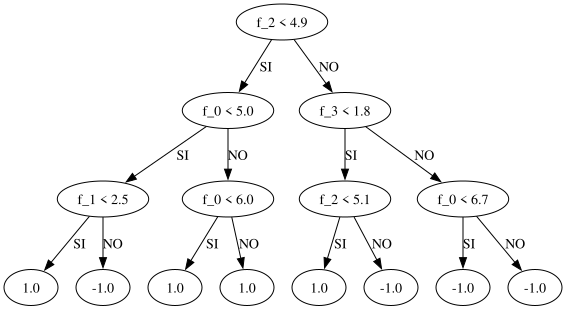

In [89]:
from  graphviz import Digraph 

tree.draw_tree()
tree.show_tree()

### Tutte le caratteristiche e i campioni

In [90]:
y = df.iloc[:, 4].values

X = df.iloc[:, [0, 1, 2, 3]].values

X_train, X_test, y_train, y_test = train_test_split(X, y)

tree = DecisionTree(max_depth=3, min_size=1)
tree.fit(X_train,y_train)
print(f"Accuratezza: {np.mean([tree.predict_batch(X_test) == y_test])}")

Accuratezza: 0.9736842105263158


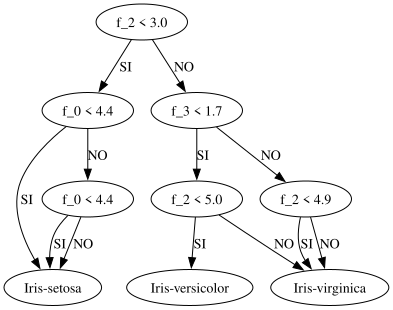

In [91]:
tree.draw_tree()
t = tree.show_tree()
t

# Riepilogo

# Alberi di decisione

$D_p$, il dataset associato al nodo $p$ dell'albero. $D_{\text{root}} = D$, il dataset iniziale.

**Indice di Gini**

$$
I_G(D_p) = \sum_{c} \frac{n_c}{n}\left( 1 - \frac{n_c}{n} \right) = 1-\sum_{c}\left(\frac{n_c}{n} \right)^2
$$

**Guadagno informativo**

$D_L$ e $D_R$, partizione di $D_p$ nel figlio sinistro e destro.

$$
IG(D_p) = I_G(D_p) - \left( \frac{|D_L|}{n} I_G(D_L) + \frac{n-|D_L|}{n} I_G(D_R) \right)
$$

In fase di addestramento (creazione dell'albero), si sceglierà la feature e il valore che indurranno una partizione di $D_p$ che renda massimo il guadagno informativo.

## Implementazione

Un *nodo interno* è un dizionario con i seguenti campi:

- `'index'`: l'indice della colonna di `X` corrispondente alla caratteristica usata per il test;
- `'value'`: il valore con cui confrontare la caratteristica
- `'groups'`: una coppia che contiene $D_L$ e $D_R$
- `'left`, `'right'`: i riferimenti ai due figli

Un *nodo foglia* è semplicemente un valore, il nome della classe.


### Definizione della classe e addestramento

Con $X$ indichiamo la matrice $n\times d$ degli $n$ indici sulle $d$ di caratteristiche; con $y$ il vettore target. Per praticità durante l'addestramento viene utilizzato un dataset che concatena orizzontalmente $X$ e $y$, quindi le prime $n$ colonne del dataset corrispondono a $X$, l'ultima a $y$.

## Esercizio

Si testi il classificatore **Decision Tree** su dataset artificiali generati utilizzando la funzione `make_classification` della libreria *scikit-learn*.

La funzione `make_classification` permette di generare dataset sintetici per problemi di classificazione controllando vari parametri come numero di feature, rumore e separabilità delle classi.

```python
from sklearn.datasets import make_classification
```

Si utilizzino più dataset variando i parametri del generatore (numero campioni, numero di features, numero di classi, numero di features significative, rumore)

In [92]:
import numpy as np
from scipy.spatial import KDTree
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X,y = make_classification(n_samples=1000, n_features=10,
                        n_informative=7, n_classes=4, random_state=0)

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

tree = DecisionTree(max_depth=10, min_size=10)
tree.fit(X_train,y_train)

print(f"Accuratezza train : {np.mean([tree.predict_batch(X_train) == y_train])}")
print(f"Accuratezza test  : {np.mean([tree.predict_batch(X_test) == y_test])}")

Accuratezza train : 0.8653333333333333
Accuratezza test  : 0.636
